# Relationship Bench — Results Analysis

Comparative analysis of LLM classification outputs across all models run against the 91-post filtered dataset.

Each model was asked to classify a r/relationship_advice post into one of six categories:
**End Relationship · Communicate · Give Space / Time · Set / Respect Boundaries · Seek Therapy / Counselling · Compromise**


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path
from itertools import combinations

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

CATEGORIES = [
    "End Relationship",
    "Communicate",
    "Give Space / Time",
    "Set / Respect Boundaries",
    "Seek Therapy / Counselling",
    "Compromise",
]
SHORT = {
    "End Relationship":        "End Rel.",
    "Communicate":             "Communicate",
    "Give Space / Time":       "Give Space",
    "Set / Respect Boundaries":"Boundaries",
    "Seek Therapy / Counselling":"Therapy",
    "Compromise":              "Compromise",
}


## 2. Load Data

In [2]:
results_dir = Path("results")
model_dfs = {}

for model_dir in sorted(results_dir.iterdir()):
    if model_dir.is_dir():
        csvs = sorted(model_dir.glob("*.csv"))
        if csvs:
            df = pd.read_csv(csvs[-1])   # latest run per model
            df["word_count"] = df["Reasoning"].str.split().str.len()
            model_dfs[model_dir.name] = df

print(f"Models loaded: {len(model_dfs)}")
for name, df in model_dfs.items():
    ok = df["Classification"].notna() & (df["Classification"] != "")
    print(f"  {name}: {ok.sum()}/{len(df)} valid")


Models loaded: 2
  claude_haiku_4_5_20251001: 91/91 valid
  gpt_5_4_mini: 91/91 valid


In [3]:
# Build a single comparison DataFrame — one column per model
comparison = None
for model_name, df in model_dfs.items():
    col = df[["ID", "Classification"]].rename(columns={"Classification": model_name})
    comparison = col if comparison is None else comparison.merge(col, on="ID")

model_cols = list(model_dfs.keys())
comparison.head()


,ID,claude_haiku_4_5_20251001,gpt_5_4_mini
0,1,Communicate,Set / Respect Boundaries
1,2,Communicate,Communicate
2,3,Communicate,Set / Respect Boundaries
3,4,Communicate,Communicate
4,5,Communicate,Communicate


## 3. Classification Distribution per Model

How often does each model pick each category? A skewed distribution flags a model that
defaults to a dominant label rather than reasoning about each case individually.


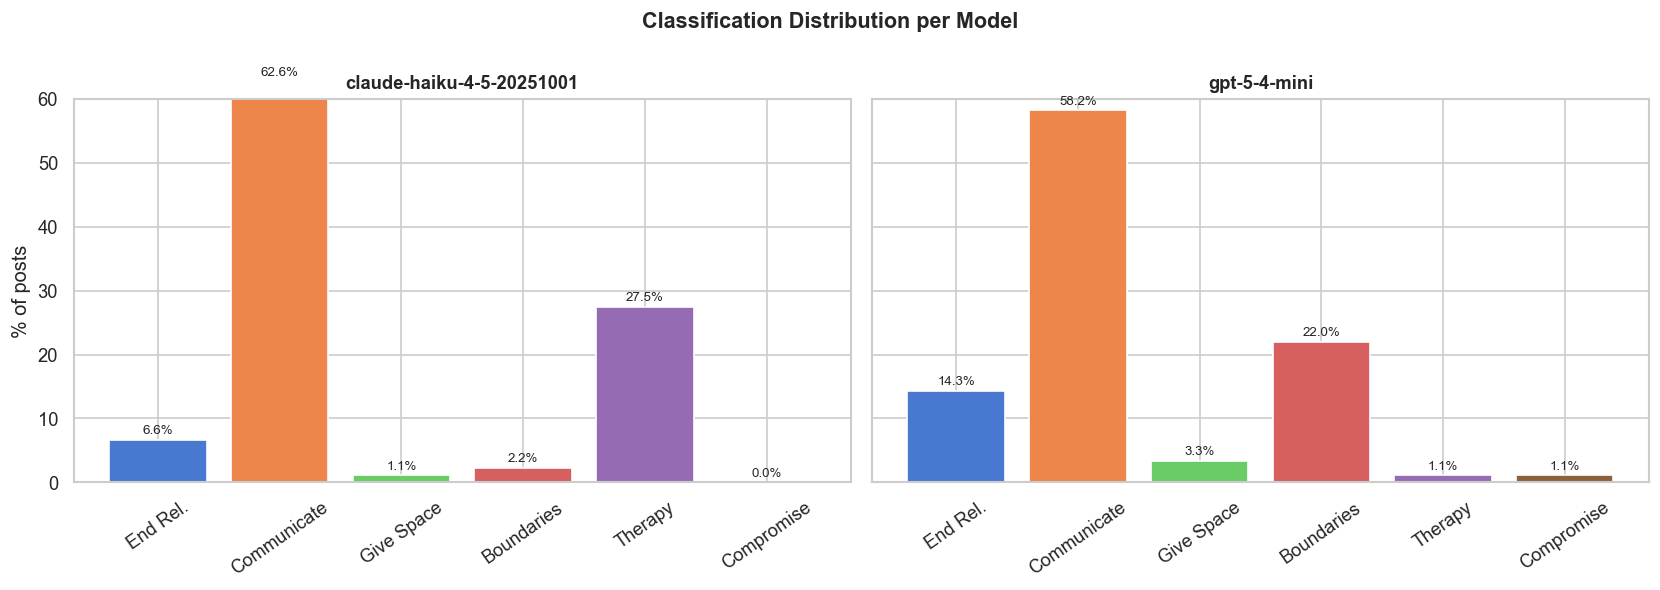

In [4]:
n_models = len(model_dfs)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

palette = sns.color_palette("muted", len(CATEGORIES))

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    counts = df["Classification"].value_counts().reindex(CATEGORIES, fill_value=0)
    pct = counts / counts.sum() * 100
    labels = [SHORT[c] for c in CATEGORIES]
    bars = ax.bar(labels, pct, color=palette)
    ax.set_title(model_name.replace("_", "-"), fontsize=11, fontweight="bold")
    ax.set_ylabel("% of posts" if ax is axes[0] else "")
    ax.set_ylim(0, 60)
    ax.tick_params(axis="x", rotation=35)
    for bar, val in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

plt.suptitle("Classification Distribution per Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_distribution.png", bbox_inches="tight")
plt.show()


In [5]:
# Raw counts table
dist_table = pd.DataFrame({
    name: df["Classification"].value_counts().reindex(CATEGORIES, fill_value=0)
    for name, df in model_dfs.items()
})
dist_table.loc["TOTAL"] = dist_table.sum()
dist_table


,claude_haiku_4_5_20251001,gpt_5_4_mini
Classification,,
End Relationship,6,13
Communicate,57,53
Give Space / Time,1,3
Set / Respect Boundaries,2,20
Seek Therapy / Counselling,25,1
Compromise,0,1
TOTAL,91,91


## 4. Pairwise Agreement & Cohen's Kappa

**Raw agreement** = % of posts where both models pick the same label.

**Cohen's κ** adjusts for chance — two models that both heavily favour "Communicate"
will agree often by accident. Kappa penalises that. Rule of thumb: κ > 0.6 is substantial,
κ > 0.8 is near-perfect.


In [6]:
pairs = list(combinations(model_cols, 2))

rows = []
for m1, m2 in pairs:
    agree = (comparison[m1] == comparison[m2]).sum()
    rate  = agree / len(comparison)
    kappa = cohen_kappa_score(comparison[m1], comparison[m2])
    rows.append({
        "Model A": m1.replace("_", "-"),
        "Model B": m2.replace("_", "-"),
        "Agreement": f"{agree}/{len(comparison)} ({rate*100:.1f}%)",
        "Cohen's κ": round(kappa, 3),
    })

pd.DataFrame(rows)


,Model A,Model B,Agreement,Cohen's κ
0,claude-haiku-4-5-20251001,gpt-5-4-mini,49/91 (53.8%),0.253


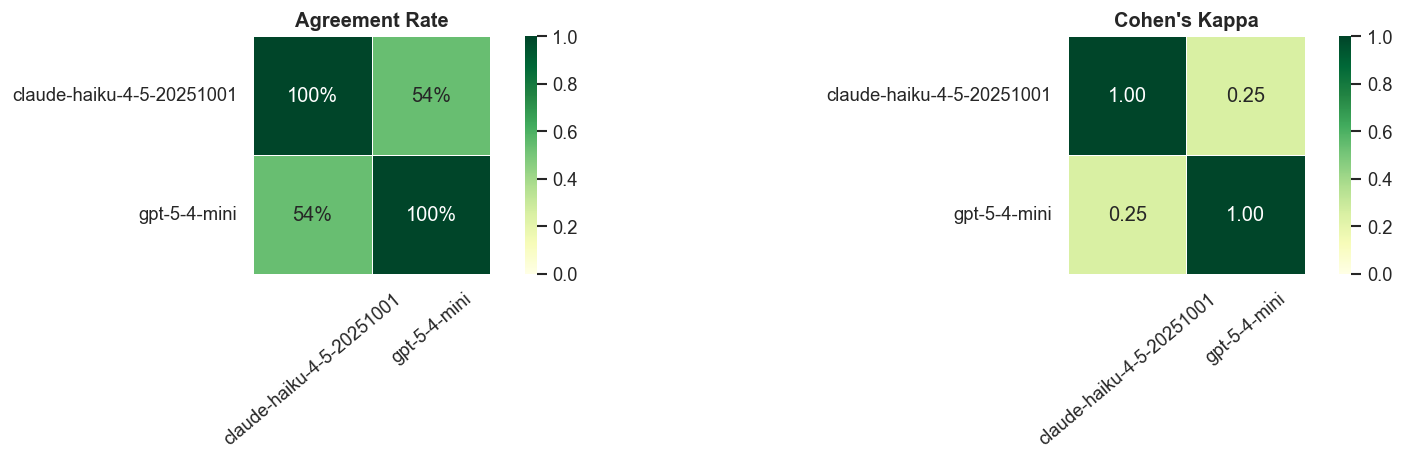

In [7]:
# Heatmap matrices — more useful once we have 3+ models
n = len(model_cols)
agree_mat = pd.DataFrame(np.eye(n), index=model_cols, columns=model_cols)
kappa_mat = pd.DataFrame(np.eye(n), index=model_cols, columns=model_cols)

for m1, m2 in pairs:
    r = (comparison[m1] == comparison[m2]).mean()
    k = cohen_kappa_score(comparison[m1], comparison[m2])
    agree_mat.loc[m1, m2] = agree_mat.loc[m2, m1] = r
    kappa_mat.loc[m1, m2] = kappa_mat.loc[m2, m1] = k

short_names = [c.replace("_", "-") for c in model_cols]
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, n * 1.5)))

for ax, mat, title, fmt in [
    (axes[0], agree_mat, "Agreement Rate",  ".0%"),
    (axes[1], kappa_mat, "Cohen's Kappa",   ".2f"),
]:
    sns.heatmap(mat.values, annot=True, fmt=fmt, vmin=0, vmax=1,
                xticklabels=short_names, yticklabels=short_names,
                cmap="YlGn", ax=ax, linewidths=0.5, square=True)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=40)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("analysis_agreement.png", bbox_inches="tight")
plt.show()


## 5. Disagreement Heatmap (Model vs Model)

For each pair, a confusion matrix where row = Model A's label and col = Model B's label.
The diagonal is agreement; off-diagonal cells show the shape of disagreement — are models
swapping *adjacent* advice (e.g. Communicate ↔ Boundaries) or *opposite* ends of the spectrum?


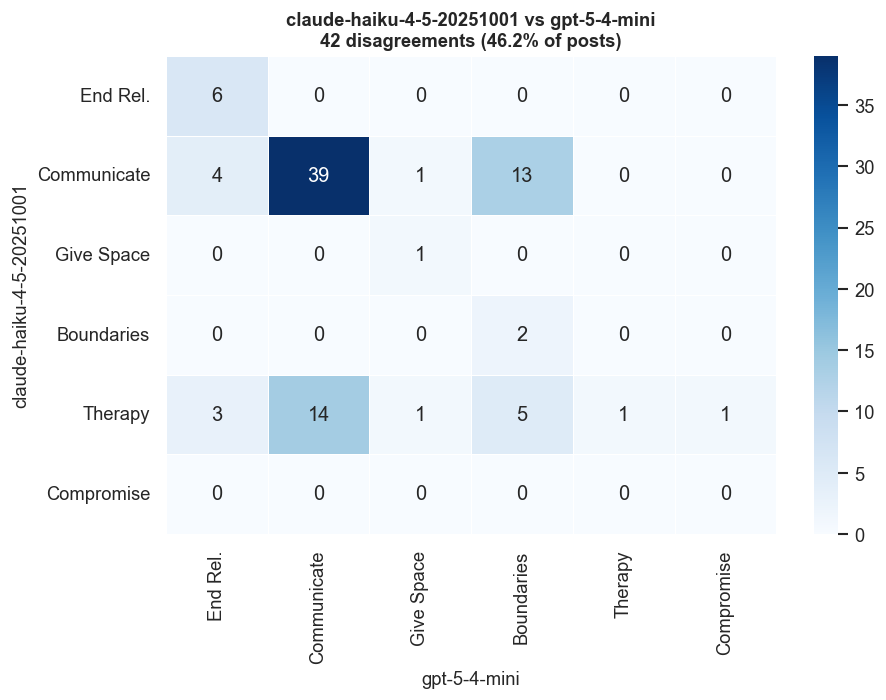

In [8]:
for m1, m2 in pairs:
    disagree_n = (comparison[m1] != comparison[m2]).sum()
    pct = disagree_n / len(comparison) * 100

    cm = confusion_matrix(comparison[m1], comparison[m2], labels=CATEGORIES)
    cm_df = pd.DataFrame(
        cm,
        index=[SHORT[c] for c in CATEGORIES],
        columns=[SHORT[c] for c in CATEGORIES],
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, ax=ax, vmin=0)
    ax.set_xlabel(m2.replace("_", "-"), fontsize=11)
    ax.set_ylabel(m1.replace("_", "-"), fontsize=11)
    ax.set_title(
        f"{m1.replace('_','-')} vs {m2.replace('_','-')}\n"
        f"{disagree_n} disagreements ({pct:.1f}% of posts)",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"analysis_confusion_{m1}_vs_{m2}.png", bbox_inches="tight")
    plt.show()


## 6. Contested Posts

Posts where models disagree are the most analytically interesting — they surface
genuine ambiguity in the advice space. We rank by number of distinct labels assigned.


In [9]:
comparison["n_unique"] = comparison[model_cols].apply(lambda r: r.nunique(), axis=1)
comparison["agreed"]   = comparison["n_unique"] == 1

total_agree = comparison["agreed"].sum()
print(f"Full agreement : {total_agree}/{len(comparison)} ({total_agree/len(comparison)*100:.1f}%)")
print(f"Contested      : {(~comparison['agreed']).sum()}")


Full agreement : 49/91 (53.8%)
Contested      : 42


In [10]:
# Pull in post content for inspection
content_df = list(model_dfs.values())[0][["ID", "Link", "Post Content"]]
contested = (
    comparison[~comparison["agreed"]]
    .merge(content_df, on="ID")
    .sort_values("n_unique", ascending=False)
)

# Display top contested posts
for _, row in contested.iterrows():
    print(f"\n{'='*70}")
    print(f"ID {int(row['ID'])}  |  {row['Link']}")
    print(f"Snippet: {str(row['Post Content'])[:300]}...")
    print()
    for m in model_cols:
        print(f"  {m.replace('_','-'):45} →  {row[m]}")



ID 1  |  https://www.reddit.com/r/relationship_advice/comments/1sjdi90/how_can_i_25f_get_my_boyfriend_23m_to_stop/
Snippet: How can I (25F) get my boyfriend (23M) to stop sufferingmaxxing?
Hey everyone,

I know the title is a little weird but hear me out.

my boyfriend (m23) really hates spending money on himself, and then complains about it.

It makes no sense, he earns six figures, has no debt/loans and virtually no co...

  claude-haiku-4-5-20251001                     →  Communicate
  gpt-5-4-mini                                  →  Set / Respect Boundaries

ID 78  |  https://www.reddit.com/r/relationship_advice/comments/1sjai1k/my_27f_boyfriend_27m_still_seems_hung_up_on_his/
Snippet: My (27F) boyfriend (27M) still seems hung up on his ex and I don’t know if I’m overthinking or ignoring red flags
Hi everyone, I could really use some outside perspective because I’m feeling anxious and confused.

My boyfriend (27M) and I (27F) have been together for about 1 year and 2 months. Overa

In [11]:
# Summary table of contested posts
contested_summary = contested[["ID"] + model_cols + ["n_unique"]].copy()
contested_summary.columns = ["ID"] + [c.replace("_","-") for c in model_cols] + ["# Distinct Labels"]
contested_summary.reset_index(drop=True)


,ID,claude-haiku-4-5-20251001,gpt-5-4-mini,# Distinct Labels
0,1,Communicate,Set / Respect Boundaries,2
1,78,Communicate,Set / Respect Boundaries,2
2,64,Communicate,Set / Respect Boundaries,2
3,66,Seek Therapy / Counselling,Set / Respect Boundaries,2
4,67,Communicate,End Relationship,2
5,68,Seek Therapy / Counselling,Set / Respect Boundaries,2
6,70,Seek Therapy / Counselling,Compromise,2
7,72,Seek Therapy / Counselling,Communicate,2
8,73,Seek Therapy / Counselling,Communicate,2
9,74,Seek Therapy / Counselling,Communicate,2


## 7. Reasoning Length

Word count of each model's reasoning, broken down by classification category.
Longer reasoning on certain categories may indicate the model finds them harder
to justify, or is naturally more verbose when giving particular types of advice.


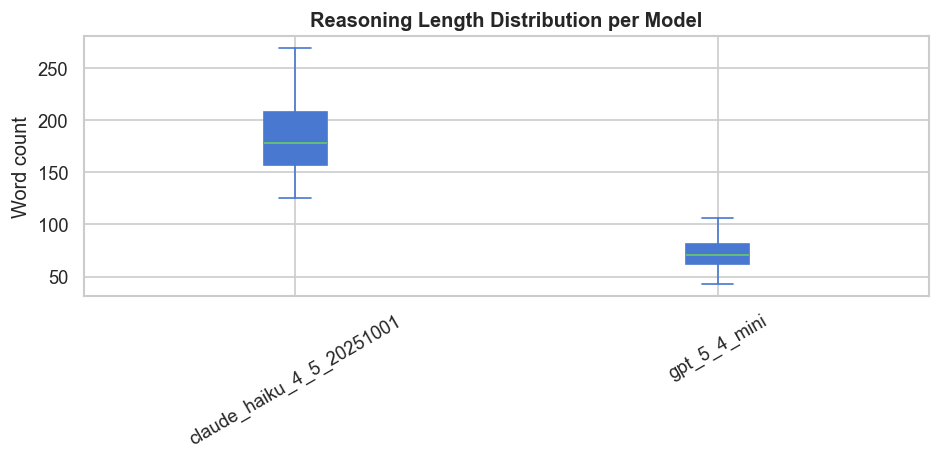

Summary statistics:
       claude_haiku_4_5_20251001  gpt_5_4_mini
count                       91.0          91.0
mean                       181.6          71.2
std                         33.5          13.4
min                        125.0          43.0
25%                        157.0          62.0
50%                        178.0          71.0
75%                        207.5          81.0
max                        269.0         106.0


In [12]:
# Overall word count distribution per model
wc_data = pd.DataFrame({
    name: df["word_count"] for name, df in model_dfs.items()
})

fig, ax = plt.subplots(figsize=(8, 4))
wc_data.plot.box(ax=ax, patch_artist=True)
ax.set_ylabel("Word count")
ax.set_title("Reasoning Length Distribution per Model", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("analysis_wordcount_overall.png", bbox_inches="tight")
plt.show()

print("Summary statistics:")
print(wc_data.describe().round(1))


/var/folders/1b/3889xdmx0db9frpm8h_1kq800000gn/T/ipykernel_42752/4233379501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cat_data, labels=[SHORT[c] for c in CATEGORIES],
/var/folders/1b/3889xdmx0db9frpm8h_1kq800000gn/T/ipykernel_42752/4233379501.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cat_data, labels=[SHORT[c] for c in CATEGORIES],


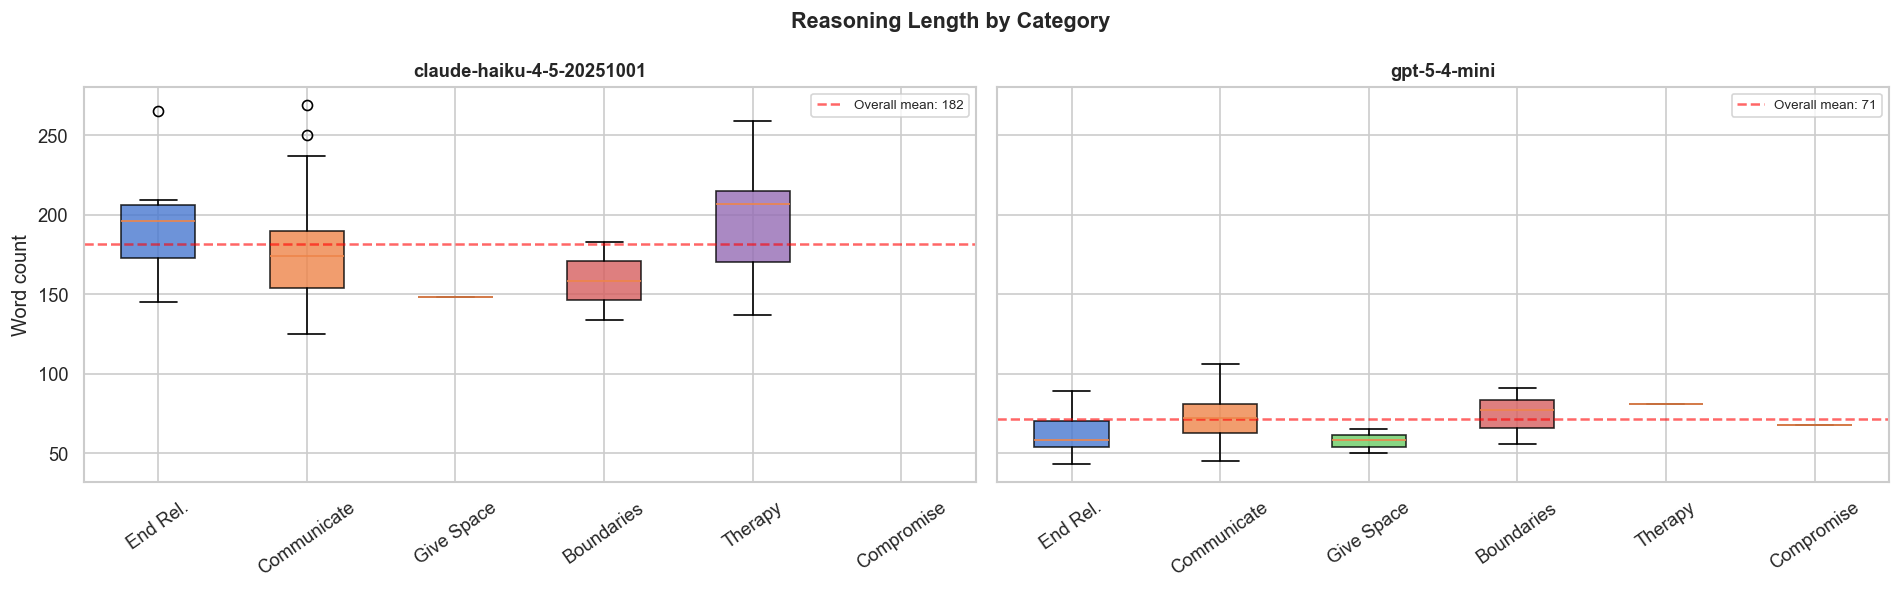

In [13]:
# Word count per category — one subplot per model
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    cat_data = [
        df[df["Classification"] == cat]["word_count"].dropna().values
        for cat in CATEGORIES
    ]
    bp = ax.boxplot(cat_data, labels=[SHORT[c] for c in CATEGORIES],
                    patch_artist=True, notch=False)
    colors = sns.color_palette("muted", len(CATEGORIES))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    mean_wc = df["word_count"].mean()
    ax.axhline(mean_wc, color="red", linestyle="--", alpha=0.6,
               label=f"Overall mean: {mean_wc:.0f}")
    ax.set_title(model_name.replace("_", "-"), fontsize=11, fontweight="bold")
    ax.set_ylabel("Word count" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(fontsize=8)

plt.suptitle("Reasoning Length by Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_wordcount_by_category.png", bbox_inches="tight")
plt.show()
